<a href="https://colab.research.google.com/github/efthimiskarl/8DM50/blob/main/GAN_practical_TF2_fixed_fit_viz_fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data synthesis using generative adversarial networks (GANs)

In this practical session we will build and train generative adversarial networks that are able to generate images.

This is a Google Colab notebook, which is mostly the same as a Jupyter notebook. This means that you can run the code in a cell by selecting the cell and pressing Shift+Enter. We will run everything in the cloud, so you don't need a fancy computer or an expensive GPU for this exercise. We are going to use GPUs that Google Cloud provides for free. To do this, go to Edit --> Notebook settings and select GPU as Hardware accelerator. Then, in the top right of this screen select 'CONNECT' --> 'Connect to hosted runtime'

We are going to import some of the packages that we will need in this exercise (by running the cell below)

The documentation for key packages can be found online: <br>
For numpy: https://docs.scipy.org/doc/numpy-dev/user/quickstart.html <br>
For matplotlib: http://matplotlib.org/api/pyplot_api.html <br>
For Keras: https://keras.io/ <br>
For random: https://docs.python.org/2/library/random.html <br>

In [ ]:
import pickle
import gzip
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rc
from matplotlib import pylab
from IPython import display

import tensorflow as tf
from tensorflow import keras
keras.backend.set_image_data_format('channels_first')

import time
import random
from google.colab import files
from google.colab import widgets
random.seed(0)

# Check whether we're using a GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

#tf.logging.set_verbosity(tf.logging.ERROR)

Found GPU at: /device:GPU:0


## Small steps
Before moving on to generating images, we will start with a simple 1D problem. We will assume that there is a data set of real samples that are drawn from a normal distribution with a particular mean value (the black dotted line below). These samples are in the sample domain *x*.

The generator network does not know anything about the distribution of the real samples in the sample domain *x*, but will try to come up with a transformation that maps random noise from a distribution *z* to samples that seem to come from the real sample distribution (the green line below). This is very similar to what we have looked at in the lecture.

<img src="https://cs.stanford.edu/people/karpathy/gan/gan.png">

For this, we will define two neural networks that play a game:
*   The discriminator will learn to distinguish real and fake samples in *z*
*   The generator will generate fake samples in *z* that the discriminator cannot discriminate

First, we determine the mean value of the normal distribution from which **real** samples will be drawn in the sample domain *x*. In addition, we define the dimensionality of the normal distribution *z* from which noise samples to the generator will be drawn, i.e. the latent space. This will be 1 for now.

In [ ]:
real_mean = 8
latent_dim = 1

Next, we define our discriminator and generator. These are both very simple networks.

**Question** How many layers does each of these networks have?

<font color="green">
Both the discriminator and the generator use the same three- layer multilayer perceptron. Each takes a one-dimensional input, feeds it to a hidden layer with 32 units, applies a LeakyReLU nonlinearity, and then maps to a single output with a final fully connected layer. The activation has no learnable parameters, so only the two fully connected layers are trainable, which mean each network has three layers, two of which are trainable.

</font>

**Question** Can you find out how many trainable parameters the networks have?


<font color="green">
For a fully connected layer with $n_{\text{in}}$ inputs and $n_{\text{out}}$ outputs, the parameter count is $n_{\text{in}}n_{\text{out}} + n_{\text{out}}$. Applying this to both models:
</font>


- **First Dense:** $1 \times 32 + 32 = 64$
- **Final Dense:** $32 \times 1 + 1 = 33$

**Total per network:** $64 + 33 = \mathbf{97}$ trainable parameters.



**Question** What are the activation functions of both networks? Why are they like this?

<font color="green">
Both networks use a LeakyReLU in the hidden layer to keep gradients non-zero for negative inputs, which prevents dead units and makes optimization in the adversarial game more stable. The discriminator ends with a sigmoid because it must output a probability of “real” versus “fake,” and the training loss is binary cross-entropy. The generator ends with a linear unit because its samples live directly in the data domain, which in this setup is unbounded. If the data were explicitly scaled to a bounded range, a bounded output such as tanh could be used instead.
</font>

In [ ]:
# For easier reading
from keras.layers import Reshape, Dense, Dropout, Flatten
from keras.layers import LeakyReLU

# The discriminator will directly classify the input value
def get_discriminator_1D():
  discriminator = keras.models.Sequential()
  discriminator.add(Dense(32, input_dim=1))
  discriminator.add(LeakyReLU())
  discriminator.add(Dense(1, activation='sigmoid'))
  return discriminator

# The generator will transform a single input value
def get_generator_1D():
  generator = keras.models.Sequential()
  generator.add(Dense(32, input_dim=1))
  generator.add(LeakyReLU())
  generator.add(Dense(1))
  return generator

Now, we will define the training functions for both networks. Consider what is actually happening in a GAN and how the inputs and outputs are connected. There are three variables when training this GAN

*   **z**: the noise that will be input to the generator
*   **G_z**: the output of the generator, i.e. the samples that should approximate the real samples
*   **D_G_z**: the discriminator's decision based on the fake sample

The overall objective function of our system is as follows

$V^{(D)}(D,G)=\underset{x\sim p_{data}}{\mathbb{E}} [\log{D(x)}]+\underset{z\sim p_z}{\mathbb{E}} [\log{(1-D(G(z)))}]$

The generator $G$ is trying to minimize this loss, and the discriminator $D$ tries to maximize this. In other words, the discriminator wants to minimize the binary cross-entropy s.t. it predicts 1 for real samples and 0 for fake samples. At the same time, the generator tries to get the discriminator to predict 1 for fake samples.




In [ ]:
# Get networks
discriminator = get_discriminator_1D()
generator = get_generator_1D()

# Configure both models for training
discriminator.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))
generator.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

# To configure the full model, we will set the 'trainable' parameter of the discriminator to False, as we don't want to optimize the discriminator when optimizing the generator
discriminator.trainable = False

# The input variable (noise) for the generator
z = keras.layers.Input(shape=(latent_dim,))

# What comes out of the generator
G_z = generator(z)

# What comes out of the discriminator when classifying the 'fake' samples
D_G_z = discriminator(G_z)

# The full GAN model
gan = keras.models.Model(inputs=z, outputs=D_G_z)

# The loss function for the GAN: this gets lower if the fake samples are classified as real
gan.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The code below runs the training loop. This could take a while. The code will periodically show a plot of the current situation.

**Question** Why do we set discriminator.trainable to either True or False?

<font color="green">
We set discriminator.trainable to either True or False to enforce alternating optimization in a GAN. When training the discriminator it is True so binary cross-entropy on real and fake batches updates only the discriminator's weights. When training the generator it is False so the discriminator serves as a fixed critic, gradients pass through it to update only the generator while the discriminator's parameters remain unchanged.

</font>


""


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

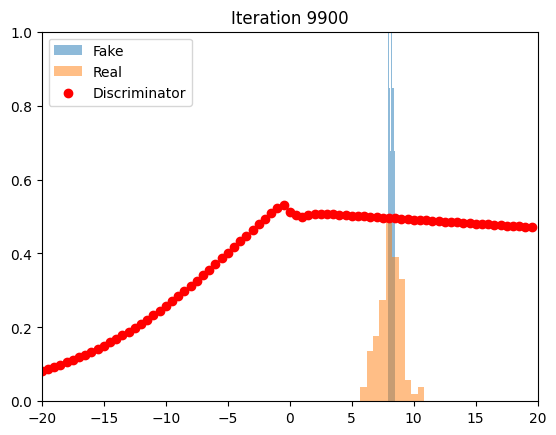

<IPython.core.display.Javascript object>

In [ ]:
# We will store the losses here
g_losses = []
d_losses = []

# Training loop
n_samples = 100
epochs = 10000

grid = widgets.Grid(1, 1)

for e in range(epochs):
  # Get a random set of input noise
  #noise = np.random.normal(0, 1, size=[n_samples, latent_dim])
  noise = np.random.uniform(-1, 1, size=[n_samples, latent_dim])
  # Also get a sample from the 'real' distribution
  real = np.random.normal(real_mean, 1, size=[n_samples, latent_dim])

  # Generate some fake samples using the generator
  fake = generator.predict(noise, verbose=0)

  # Concatenate the fake and real images
  X = np.concatenate([real, fake])

  # Labels for generated and real data
  Y_dis = np.zeros(2 * n_samples)

  # Set labels for real samples to 1
  Y_dis[:n_samples] = 1

  # Train discriminator with this batch of samples
  discriminator.trainable = True
  d_loss = discriminator.fit(X, Y_dis, batch_size=n_samples, epochs=1, verbose=0)

  # Train generator with a new batch of generated samples
  # Freeze the discriminator part
  discriminator.trainable = False
  # noise = np.random.normal(0, 1, size=[n_samples, latent_dim])
  noise = np.random.uniform(-1, 1, size=[n_samples, latent_dim])
  # From the generator's perspective, the discriminator should predict
  # ones for all samples
  Y_gen = np.ones(n_samples)
  g_loss = gan.fit(noise, Y_gen, batch_size=n_samples, epochs=1, verbose=0)


  if e % 100 == 0:
    #noise = np.random.normal(0, 1, size=[n_samples, latent_dim])
    noise = np.random.uniform(-1, 1, size=[n_samples, latent_dim])
    fake = generator.predict(noise, verbose=0)
    real = np.random.normal(real_mean, 1, size=[n_samples, latent_dim])
    pred = discriminator.predict(np.arange(-20, 20, 0.5).reshape((80, 1)), verbose=0)

    with grid.output_to(0, 0):
      grid.clear_cell()

      # Clear previous plots and create a new figure
      plt.clf()
      fig, ax = plt.subplots()

      # Plot histogram for real and fake data
      ax.hist(np.squeeze(fake), density=True, alpha=0.5, label='Fake')
      ax.hist(np.squeeze(real), density=True, alpha=0.5, label='Real', stacked=True)

      # Scatter plot for discriminator predictions
      ax.scatter(np.arange(-20, 20, 0.5), pred, c='r', label='Discriminator')

      # Set plot limits and labels
      ax.set_xlim(-20, 20)
      ax.set_ylim(0, 1)
      ax.set_title('Iteration {}'.format(e))

      # Add legend
      ax.legend()

      # Display the plot
      plt.show()


Although it is definitely nice that we can train two networks together to learn the distribution of a real data distribution, generating samples from a normal distribution is in itself not really interesting. Luckily, we can use the same principles to generate images.

If all is well, the fake and real distributions should nicely overlap after training. The discriminator has essentially pushed the fake samples towards the real distribution and the generator is now able to transform the noise distribution into a distribution of 'real' samples!

**Question** Can you explain what happened to the red line during training? Why does it look like it does after training?

<font color="green">
for x values above 0 the discriminator has a value of 0.5, meaning that it can't clearly identify if a sample if real or fake.
</font>

**Question** Try training the GAN with different input noise distributions, e.g. uniform.

<font color="green">
The GAN was trained with a uniform distribution.
The distributions do not fit eachother nicely anymore.
</font>


**Question** See if you can find a distribution for the real samples for which the generator fails to generate samples.

<font color="green">
The generator would probably fail to generate samples from a multinomial distribution
</font>

# MNIST synthesis
Like last week, we are again going to use MNIST data. Data preparation is the same as before.

In [ ]:
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# load the MNIST the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# scale the image intensities to the 0-1 range
x_train = (x_train / 255.0).astype(np.float32)
x_test = (x_test / 255.0).astype(np.float32)

# convert the data to channel-last
train_set_images = np.expand_dims(x_train, axis=-1)
test_set_images = np.expand_dims(x_test, axis=-1)

# convert the labels to one-hot encoded
train_set_labels = to_categorical(y_train, num_classes=10)
test_set_labels = to_categorical(y_test, num_classes=10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Plot some images.

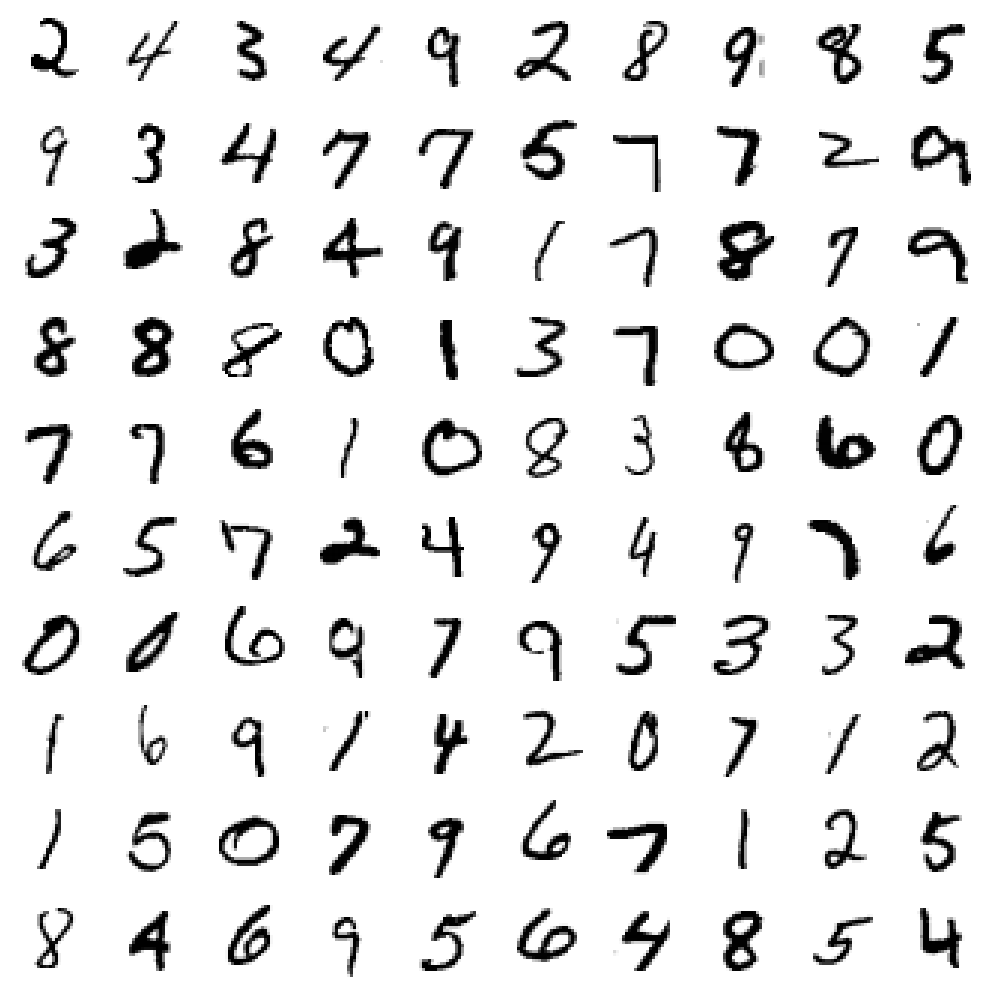

In [ ]:
def plotImages(images, dim=(10, 10), figsize=(10, 10), title=''):
    plt.figure(figsize=figsize)
    for i in range(images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(images[i], interpolation='nearest', cmap='gray_r')
        plt.axis('off')
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()

plotImages(train_set_images[np.random.randint(0, train_set_images.shape[0], size=100)].reshape(100, 28, 28))

In last week's exercise you have built a discriminative model that was able to classify an image into one of ten digit categories. In this exercise, we are going to do the inverse. Given a point in a latent space (which in our case will be a multi-dimensional Gaussian distribution), we are going to train the network to generate a realistic digit image for this point. The MNIST data set will be used as a set of real samples.


## The discriminator
As you can see in the image above, we will need a generator and a discriminator network. Let's define these. Consider the network that you used
for digit classification in the previous exercise and see if you can spot some differences between that network and the network below.

**Question** Is this a convolutional neural network? Why (not)?

<font color="green">
No, it is not a convolutional neural network. It is a multilayer perceptron that first flattens each 28x28 image into a 784 dimensional vector and then applies fully connected Dense layers with LeakyReLU and Dropout. There are no Conv2D or transposed convolution layers, no kernels, strides, padding, or pooling, and therefore no weight sharing across spatial locations.

</font>

In [ ]:
def get_discriminator_MLP():
  discriminator = keras.models.Sequential()
  discriminator.add(Dense(1024, input_dim=784, kernel_initializer=keras.initializers.RandomNormal(stddev=0.02)))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dropout(0.3))
  discriminator.add(Dense(512))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dropout(0.3))
  discriminator.add(Dense(256))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dense(1, activation='sigmoid'))
  return discriminator

You could argue that digits are a bit more complex than samples from a Gaussian distribution, so let's set the latent space dimensionality for noise sampling a bit higher than 1.

In [ ]:
latent_dim = 10


## The generator

The generator is different than the discriminator. It should go from a low-dimensional noise vector to an MNIST image.

In [ ]:
def get_generator_MLP():
  generator = keras.models.Sequential()
  generator.add(Dense(256, input_dim=latent_dim, kernel_initializer=keras.initializers.RandomNormal(stddev=0.02)))
  generator.add(LeakyReLU(0.2))
  generator.add(Dense(512))
  generator.add(LeakyReLU(0.2))
  generator.add(Dense(1024))
  generator.add(LeakyReLU(0.2))
  generator.add(Dense(784, activation='tanh'))
  return generator

**Question** Consider the activation functions of the output layers of the generator and discriminator networks. How are they different?

<font color="green">
The generator ends with a tanh activation that outputs zero-centered pixel intensities in [−1,1] for image synthesis, while the discriminator ends with a sigmoid activation that returns a single scalar in (0,1) interpreted as the probability that an input is real, matching the binary classification objective with cross-entropy.

</font>

**Question** Also look at the activation functions of the other layers, can you find out what they do? Look at the Keras documentation.

<font color="green">
In the other layers the network uses LeakyReLU with α=0.2, which outputs x for x>0 and αx for x≤0 to keep small negative-side gradients and avoid dead units. Dense layers without an explicit activation are linear so the nonlinearity is provided by the following LeakyReLU, Dropout with rate p randomly sets a fraction p of activations to zero during training and is disabled at inference to reduce overfitting.

</font>

## The model
Now  let's combine the generator and the discriminator. We train both using a binary crossentropy objective. This is very similar to what we did before.

In [ ]:
discriminator = get_discriminator_MLP()
generator = get_generator_MLP()

discriminator.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))
generator.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

discriminator.trainable = False
z = keras.layers.Input(shape=(latent_dim,))
G_z = generator(z)
D_G_z = discriminator(G_z)
gan = keras.models.Model(inputs=z, outputs=D_G_z)
gan.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

Some helper functions.

In [ ]:
def saveModels(epoch):
    generator.save('gan_generator_epoch_{}.h5'.format(epoch))
    discriminator.save('gan_discriminator_epoch_{}.h5'.format(epoch))

def plotGeneratedImages(epoch, examples=100, dim=(10, 10), figsize=(10, 10)):
    noise = np.random.normal(0, 1, size=[examples, latent_dim])
    generatedImages = generator.predict(noise)
    generatedImages = generatedImages.reshape(examples, 28, 28)

    plt.figure(figsize=figsize)
    for i in range(generatedImages.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(generatedImages[i], interpolation='nearest', cmap='gray_r')
        plt.axis('off')
    plt.tight_layout()
    plt.suptitle('Epoch {}'.format(epoch))
    plt.show()

Run the code below to train the GAN model. Synthesized images should be shown periodically.

0
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


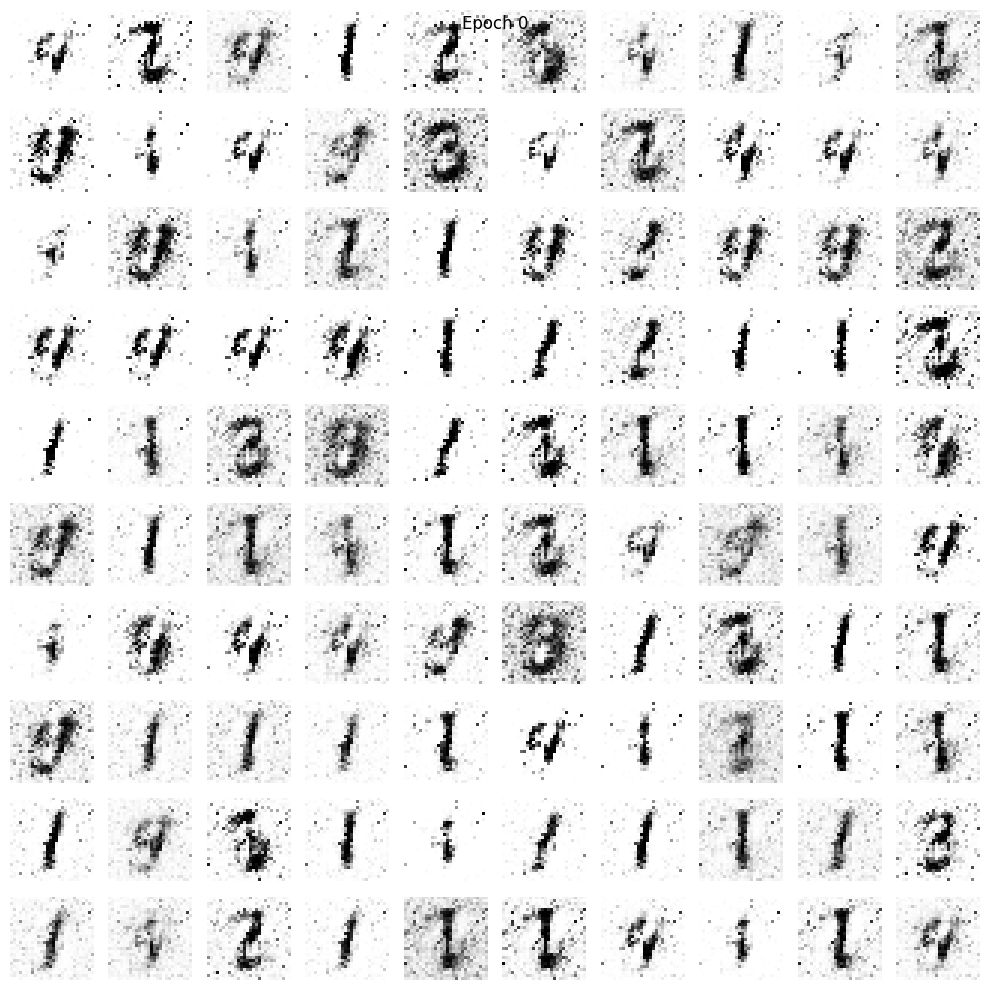

1


In [ ]:
epochs = 2  # 200
batch_size = 128

X_train = (train_set_images.reshape(60000, 784).astype(np.float32) - 0.5) / 0.5

# Labels for real and fake images
real_labels = np.ones((batch_size, 1)) * 0.9  # One-sided label smoothing
fake_labels = np.zeros((batch_size, 1))

for e in range(epochs):
    # Train discriminator and generator on each batch
    print(e)
    for _ in range(int(X_train.shape[0] / batch_size)):

        # Get a random set of input noise and images
        noise = np.random.normal(0, 1, size=[batch_size, latent_dim])
        image_batch = X_train[np.random.randint(0, X_train.shape[0], size=batch_size)]

        # Generate some fake MNIST images using the generator
        generated_images = generator.predict(noise, verbose=0)

        # Concatenate the fake and real images
        X = np.concatenate([image_batch, generated_images])

        # Labels for concatenated real and fake images
        y_dis = np.concatenate([real_labels, fake_labels])

        # Train the discriminator
        discriminator.trainable = True
        d_loss = discriminator.fit(X, y_dis, batch_size=batch_size, verbose=0)

        # Train generator with a new batch of generated samples
        noise = np.random.normal(0, 1, size=[batch_size, latent_dim])

        # From the generator's perspective, the discriminator should predict ones for all samples
        y_gen = np.ones((batch_size, 1))

        # Freeze the discriminator
        discriminator.trainable = False

        # Train the GAN to predict ones
        g_loss = gan.fit(noise, y_gen, batch_size=batch_size, verbose=0)

    if e % 5 == 0:
        noise = np.random.normal(0, 1, size=[100, latent_dim])
        plotGeneratedImages(e)
        # display.display(plt.gcf()) # NOTE These are not necessary in colab, but might be necessary in another IDE
        # display.clear_output(wait=True)
        time.sleep(0.001)
        saveModels(e)


## A convolutional model
Thus far the discriminator and generator were both multilayer perceptrons. Now we're going to add in some convolutional layers to turn them into a deep convolutional GAN (<a href="http://arxiv.org/abs/1511.06434">DCGAN</a>)-like architecture. This means that we have to redefine the generator network and a discriminator network.

The discriminator network is (almost) the same network that we used in last week's exercise.

In [ ]:
from keras.layers import Conv2D, UpSampling2D

def get_discriminator_CNN():
  discriminator = keras.models.Sequential()
  discriminator.add(Conv2D(64, kernel_size=(5, 5), strides=(2, 2), padding='same', input_shape=(1, 28, 28), kernel_initializer=keras.initializers.RandomNormal(stddev=0.02)))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dropout(0.3))
  discriminator.add(Conv2D(128, kernel_size=(5, 5), strides=(2, 2), padding='same'))
  discriminator.add(LeakyReLU(0.2))
  discriminator.add(Dropout(0.3))
  discriminator.add(Flatten())
  discriminator.add(Dense(1, activation='sigmoid'))
  return discriminator

def get_generator_CNN():
  generator = keras.models.Sequential()
  generator.add(Dense(128*7*7, input_dim=latent_dim, kernel_initializer=keras.initializers.RandomNormal(stddev=0.02)))
  generator.add(LeakyReLU(0.2))
  generator.add(Reshape((128, 7, 7)))
  generator.add(UpSampling2D(size=(2, 2)))
  generator.add(Conv2D(64, kernel_size=(5, 5), padding='same'))
  generator.add(LeakyReLU(0.2))
  generator.add(UpSampling2D(size=(2, 2)))
  generator.add(Conv2D(1, kernel_size=(5, 5), padding='same', activation='tanh'))
  return generator

Let's build our model like before.

In [ ]:
discriminator = get_discriminator_CNN()
generator = get_generator_CNN()

discriminator.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))
generator.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

discriminator.trainable = False
z = keras.layers.Input(shape=(latent_dim,))
x = generator(z)
D_G_z = discriminator(x)
gan = keras.models.Model(inputs=z, outputs=D_G_z)
gan.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

Train the model using the code below. Inspect the samples that come out.

**Question** What are some differences between these samples and the ones generated by the multilayer perceptron GAN? Can you explain these differences?

<font color="green">
Compared with the multilayer perceptron GAN, the convolutional GAN produces sharper, more spatially coherent samples with cleaner digit strokes and fewer blobby artifacts this follows from the convolutional inductive bias, where local receptive fields and weight sharing learn spatial features while the MLP flattens images and treats pixels independently, which promotes over-smoothing. The conv generator also upsamples via transposed convolutions so small feature maps expand into images in a structured way, yielding crisper contours than a dense layer mapping noise directly to 784 values. Overall this architecture fits image statistics better, improving stability and mode coverage and giving more diverse, realistic digits.

</font>


In [ ]:
d_losses = []
g_losses = []

epochs = 2  # 200
batch_size = 128

X_train = (train_set_images.reshape(60000, 1, 28, 28).astype(np.float32) - 0.5) / 0.5

# Labels for real and fake images
real_labels = np.ones((batch_size, 1))  # Set reference to 1 for real samples
fake_labels = np.zeros((batch_size, 1))

for e in range(epochs):
    # Train discriminator and generator on each batch
    for _ in range(int(X_train.shape[0] / batch_size)):

        # Get a random set of input noise and images
        noise = np.random.normal(0, 1, size=[batch_size, latent_dim])
        image_batch = X_train[np.random.randint(0, X_train.shape[0], size=batch_size)]

        # Generate some fake MNIST images using the generator
        generated_images = generator.predict(noise, verbose=0)

        # Concatenate the fake and real images
        X = np.concatenate([image_batch, generated_images])

        # Labels for concatenated real and fake images
        y_dis = np.concatenate([real_labels, fake_labels])

        # Train the discriminator
        discriminator.trainable = True
        d_loss = discriminator.fit(X, y_dis, batch_size=batch_size, verbose=0)

        # Train generator with a new batch of generated samples
        noise = np.random.normal(0, 1, size=[batch_size, latent_dim])

        # From the generator's perspective, the discriminator should predict ones for all samples
        y_gen = np.ones((batch_size, 1))

        # Freeze the discriminator
        discriminator.trainable = False

        # Train the GAN to predict ones
        g_loss = gan.fit(noise, y_gen, batch_size=batch_size, verbose=0)

    # Store the loss of the most recent batch from this epoch
    d_losses.append(d_loss.history['loss'][-1])
    g_losses.append(g_loss.history['loss'][-1])

    if e % 5 == 0:
        noise = np.random.normal(0, 1, size=[100, latent_dim])
        generatedImages = generator.predict(noise, verbose=0)
        generatedImages = generatedImages.reshape(100, 28, 28)
        plotImages(generatedImages, title='Epoch {}'.format(e))
        # display.display(plt.gcf())
        # display.clear_output(wait=True)
        time.sleep(0.001)
        saveModels(e)


## Interpolation in the latent space
We're going to explore the latent space a bit more. We pick two points in the latent space and make a linear interpolation between these two. Then we generate images from each of the interpolated latent points.

In [ ]:
noise_a = np.random.normal(0, 1, size=[1, latent_dim])
noise_b = np.random.normal(0, 1, size=[1, latent_dim])

noise = np.zeros((10, latent_dim), dtype='float32')
for ni in range(10):
  noise[ni, :] = float(ni)/10. * noise_a + (1 - float(ni)/10.) * noise_b
generatedImages = generator.predict(noise)
generatedImages = generatedImages.reshape(10, 28, 28)
plotImages(generatedImages, dim=(1, 10), figsize=(10, 10))

**Question** Explain what you see in this plot.

<font color="green">
In this plot you can see how the latent space encodes the transition between differing numbers. The smooth transition shows the latent space has learned meaningful representations, so it's not just memorizing but capturing continuous features of digits.
</font>

**Question** What happens when you extrapolate out of the latent space distribution? Consider how the noise vectors are drawn.

<font color="green">
The generator was only trained on the typical latent space distribution. By extrapolating out of the latent space, you decode points that the decoder was not meant to decode, leading to images that likely do not bear great resemblance to the training data.
</font>

# Histopathology image synthesis

Now we're going to synthesize some actual images. We're going to use the PatchCamelyon data set ([more info here](https://github.com/basveeling/pcam)) which consists of small images that can be used for classification benchmarks. Today, we're not going to classify images, but we're going to synthesize them. You can download a data set of smaller (28 x 28 pixels) versions of these images from
[this link](https://drive.google.com/file/d/11tkBWleY6PqFAGQHW0zYOwhvuz0kq-ai/view?usp=sharing). Upload the data set in the dialog below.

In [ ]:
uploaded = files.upload()

Now load the data set.

In [ ]:
def loadPatchCamelyon(path):
    f = gzip.open(path, 'rb')
    train_set = pickle.load(f, encoding='latin1')
    f.close()
    return train_set

In [ ]:
train_set_images = loadPatchCamelyon(r'valid_28.pkl.gz')

def plotImagesPatchCamelyon(images, dim=(10, 10), figsize=(10, 10), title=''):
    plt.figure(figsize=figsize)
    for i in range(images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        plt.imshow(images[i], interpolation='nearest')
        plt.axis('off')
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()


plotImagesPatchCamelyon(train_set_images[np.random.randint(0, train_set_images.shape[0], size=100)].reshape(100, 28, 28, 3)/255.0)

What do you immediately notice? Indeed, these images are in color! So the generator will have to generate three output channels instead of just one.

In this second-to-last part of the practical you're going to repurpose the code that you have used so far to synthesize histopathology images like the ones above. You can play around a bit with this, see what happens when you interpolate between samples, etc. Remember that there is a final 'exercise' below.

**Good luck!**

In [ ]:
keras.backend.set_image_data_format('channels_last')

def get_generator_CNN():
    generator = keras.models.Sequential()
    generator.add(keras.layers.Input(shape=(latent_dim,)))
    generator.add(Dense(128*7*7, kernel_initializer=keras.initializers.RandomNormal(stddev=0.02)))
    generator.add(LeakyReLU(0.2))
    generator.add(Reshape((7, 7, 128)))  # Channel-last
    generator.add(UpSampling2D(size=(2, 2)))
    generator.add(Conv2D(64, kernel_size=(5, 5), padding='same'))
    generator.add(LeakyReLU(0.2))
    generator.add(UpSampling2D(size=(2, 2)))
    generator.add(Conv2D(3, kernel_size=(5, 5), padding='same', activation='tanh'))
    return generator

def get_discriminator_CNN():
    discriminator = keras.models.Sequential()
    discriminator.add(keras.layers.Input(shape=(28, 28, 3)))  # Channel-last
    discriminator.add(Conv2D(64, kernel_size=(5, 5), strides=(2, 2), padding='same',
                            kernel_initializer=keras.initializers.RandomNormal(stddev=0.02)))
    discriminator.add(LeakyReLU(0.2))
    discriminator.add(Dropout(0.3))
    discriminator.add(Conv2D(128, kernel_size=(5, 5), strides=(2, 2), padding='same'))
    discriminator.add(LeakyReLU(0.2))
    discriminator.add(Dropout(0.3))
    discriminator.add(Flatten())
    discriminator.add(Dense(1, activation='sigmoid'))
    return discriminator


X_train = (train_set_images.astype(np.float32) - 0.5) / 0.5  # Normalize to [-1, 1]
# X_train = np.transpose(X_train, (0, 3, 1, 2))

# Update plotting function (no transpose needed)
def plotColorImages(images, dim=(10, 10), figsize=(10, 10), title=''):
    plt.figure(figsize=figsize)
    for i in range(images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        # No transpose needed - already channel-last
        img = images[i]
        img = (img + 1) / 2.0  # Denormalize
        plt.imshow(img, interpolation='nearest')
        plt.axis('off')
    plt.tight_layout()
    plt.suptitle(title)
    plt.show()


In [ ]:
# Training parameters
d_losses = []
g_losses = []
epochs = 5
batch_size = 128
latent_dim = 16

discriminator = get_discriminator_CNN()
generator = get_generator_CNN()

discriminator.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))
generator.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

discriminator.trainable = False
z = keras.layers.Input(shape=(latent_dim,))
x = generator(z)
D_G_z = discriminator(x)
gan = keras.models.Model(inputs=z, outputs=D_G_z)
gan.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

# Labels for real and fake images
real_labels = np.ones((batch_size, 1))
fake_labels = np.zeros((batch_size, 1))

# Training loop
for e in range(epochs):
    epoch_d_loss = []
    epoch_g_loss = []

    for _ in range(int(X_train.shape[0] / batch_size)):
        # Get a random set of input noise and images
        noise = np.random.normal(0, 1, size=[batch_size, latent_dim])
        image_batch = X_train[np.random.randint(0, X_train.shape[0], size=batch_size)]

        # Generate fake images
        generated_images = generator.predict(noise, verbose=0)

        # Train discriminator
        X = np.concatenate([image_batch, generated_images])
        y_dis = np.concatenate([real_labels, fake_labels])

        discriminator.trainable = True
        d_loss = discriminator.fit(X, y_dis, batch_size=batch_size, verbose=0)
        epoch_d_loss.append(d_loss.history['loss'][-1])

        # Train generator
        noise = np.random.normal(0, 1, size=[batch_size, latent_dim])
        y_gen = np.ones((batch_size, 1))

        discriminator.trainable = False
        g_loss = gan.fit(noise, y_gen, batch_size=batch_size, verbose=0)
        epoch_g_loss.append(g_loss.history['loss'][-1])

    # Store average losses for the epoch
    d_losses.append(np.mean(epoch_d_loss))
    g_losses.append(np.mean(epoch_g_loss))

    # Generate sample images every 5 epochs
    if e % 5 == 0:
        print(f"Epoch {e}, D_loss: {d_losses[-1]:.4f}, G_loss: {g_losses[-1]:.4f}")
        noise = np.random.normal(0, 1, size=[100, latent_dim])
        generatedImages = generator.predict(noise, verbose=0)
        plotColorImages(generatedImages, title=f'Epoch {e}')
        saveModels(e)

# Final interpolation demo
print("Final interpolation demo:")
noise_a = np.random.normal(0, 1, size=[1, latent_dim])
noise_b = np.random.normal(0, 1, size=[1, latent_dim])

noise = np.zeros((10, latent_dim), dtype='float32')
for ni in range(10):
    noise[ni, :] = float(ni)/10. * noise_a + (1 - float(ni)/10.) * noise_b

generatedImages = generator.predict(noise)
plotColorImages(generatedImages, dim=(1, 10), figsize=(15, 2))

# Plot training losses
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
## YOUR CODE GOES HERE